In [1]:
import numpy as np
from ibrl.infrabayesian import AMeasure,Infradistribution

In [2]:
# Define some arbitrary a-measures
m1 = AMeasure.pure(np.array([0.1,0.9]))
m2 = AMeasure.pure(np.array([0.2,0.8]))
m3 = AMeasure.pure(np.array([0.3,0.7]))

# Some prior distribution
prior = np.array([0.6,0.4])

## Examples

In [3]:
# No prior, no KU
print(Infradistribution([m1]))

[(1.000[1.00:{0.1,0.9}],0.000)]


In [4]:
# 60-40 prior, no KU
print(Infradistribution.mix([
    Infradistribution([m1]),
    Infradistribution([m2])
], prior))

[(1.000[0.60:{0.1,0.9},0.40:{0.2,0.8}],0.000)]


In [5]:
# No prior, KU
print(Infradistribution([m1,m2]))

[(1.000[1.00:{0.1,0.9}],0.000), (1.000[1.00:{0.2,0.8}],0.000)]


In [6]:
# Prior over KU
print(Infradistribution.mix([
    Infradistribution([m1]),
    Infradistribution([m2,m3])
], prior))

[(1.000[0.60:{0.1,0.9},0.40:{0.2,0.8}],0.000), (1.000[0.60:{0.1,0.9},0.40:{0.3,0.7}],0.000)]


In [7]:
# Prior over KU, the other way around
print(Infradistribution.mixKU([
    Infradistribution.mix([
        Infradistribution([m1]),
        Infradistribution([m2])
    ], prior),
    Infradistribution.mix([
        Infradistribution([m1]),
        Infradistribution([m3])
    ], prior)
]))

[(1.000[0.60:{0.1,0.9},0.40:{0.2,0.8}],0.000), (1.000[0.60:{0.1,0.9},0.40:{0.3,0.7}],0.000)]


In [ ]:
# KU over prior
print(Infradistribution.mixKU([
    Infradistribution.mix([
        Infradistribution([m1]),
        Infradistribution([m2])
    ], prior),
    Infradistribution([m3])
]))

[(1.000[0.60:{0.1,0.9},0.40:{0.2,0.8}],0.000), (1.000[1.00:{0.3,0.7}],0.000)]


In [9]:
# Nested: prior over KU over prior over KU
print(Infradistribution.mix([
        Infradistribution.mixKU([
            Infradistribution.mix([
                Infradistribution([m1]),
                Infradistribution([m2])
            ], prior),
            Infradistribution.mix([
                Infradistribution([m1]),
                Infradistribution([m2,m3])
            ], prior)
        ]),
        Infradistribution([m2])
    ],
    prior)
)

[(1.000[0.36:{0.1,0.9},0.24:{0.2,0.8},0.40:{0.2,0.8}],0.000), (1.000[0.36:{0.1,0.9},0.24:{0.2,0.8},0.40:{0.2,0.8}],0.000), (1.000[0.36:{0.1,0.9},0.24:{0.3,0.7},0.40:{0.2,0.8}],0.000)]


## Check relation

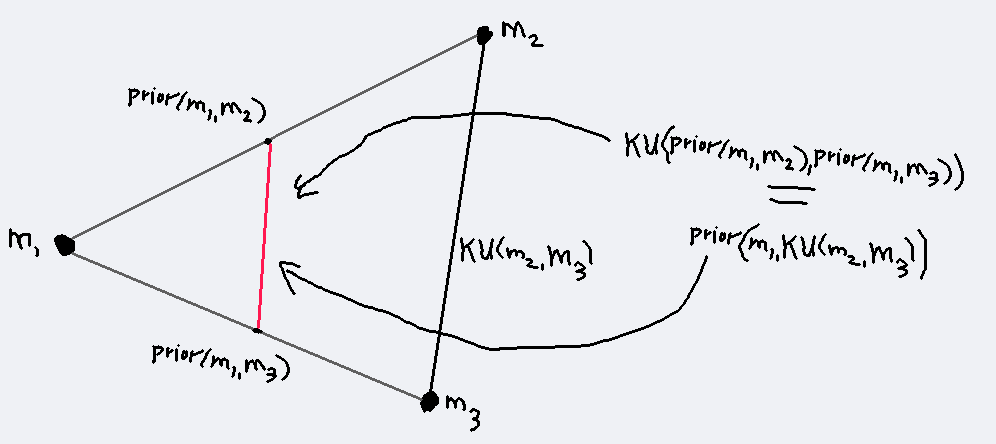

In [10]:
dist1 = Infradistribution.mix([     # prior(
    Infradistribution([m1]),        #   m1
    Infradistribution([m2,m3])      #   KU(m2,m3)
], prior)                           # )

dist2 = Infradistribution.mixKU([   # KU(
    Infradistribution.mix([         #   prior(
        Infradistribution([m1]),    #       m1,
        Infradistribution([m2])     #       m2
    ], prior),                      #   ),
    Infradistribution.mix([         #   prior(
        Infradistribution([m1]),    #       m1,
        Infradistribution([m3])     #       m3
    ], prior)                       #   )
])                                  # )

print(repr(dist1) == repr(dist2))

True


## Sanity checks

Need to clean up duplicates when constructing mixtures. So far, some of these fail

In [14]:
# KU over same a-measure -> should be same as single a-measure
print(Infradistribution([m1]))
print(Infradistribution([m1,m1]))
print(Infradistribution.mixKU([Infradistribution([m1]),Infradistribution([m1])]))

[(1.000[1.00:{0.1,0.9}],0.000)]
[(1.000[1.00:{0.1,0.9}],0.000), (1.000[1.00:{0.1,0.9}],0.000)]
[(1.000[1.00:{0.1,0.9}],0.000), (1.000[1.00:{0.1,0.9}],0.000)]


In [15]:
# Prior over same a-measure -> should be same as single a-measure
print(Infradistribution([m1]))
print(Infradistribution.mix([Infradistribution([m1]),Infradistribution([m1])], prior))

[(1.000[1.00:{0.1,0.9}],0.000)]
[(1.000[0.60:{0.1,0.9},0.40:{0.1,0.9}],0.000)]


In [17]:
# KU over KU
print(Infradistribution([m1,m2,m3]))
print(Infradistribution.mixKU([Infradistribution([m1]),Infradistribution([m2,m3])]))

[(1.000[1.00:{0.1,0.9}],0.000), (1.000[1.00:{0.2,0.8}],0.000), (1.000[1.00:{0.3,0.7}],0.000)]
[(1.000[1.00:{0.1,0.9}],0.000), (1.000[1.00:{0.2,0.8}],0.000), (1.000[1.00:{0.3,0.7}],0.000)]


In [18]:
# Prior over prior
print(Infradistribution.mix([Infradistribution([m1]),Infradistribution([m2]),Infradistribution([m3])], np.array([0.5,0.25,0.25])))
print(Infradistribution.mix([Infradistribution([m1]),Infradistribution.mix([Infradistribution([m2]),Infradistribution([m3])], np.array([0.5,0.5]))], np.array([0.5,0.5])))

[(1.000[0.50:{0.1,0.9},0.25:{0.2,0.8},0.25:{0.3,0.7}],0.000)]
[(1.000[0.50:{0.1,0.9},0.25:{0.2,0.8},0.25:{0.3,0.7}],0.000)]
